# Gateway Kartplex

October 2, 2025

In [13]:
# timestamp aligned sensor data
files = [
    '/Users/nathanverrill/Boschertown/gateway/sessions/four.csv'
]

## load and prep data

In [21]:
import pandas as pd
import numpy as np
from scipy import interpolate
from datetime import datetime

def interpolate_race_data(input_file, output_file, target_frequency_hz=10):
    """
    Interpolate race sensor data for smooth visualization in Kepler.gl
    
    Parameters:
    - input_file: Path to input CSV
    - output_file: Path to output CSV
    - target_frequency_hz: Target sampling rate (default 10Hz = 0.1s intervals)
    """
    
    # Read the data
    df = pd.read_csv(input_file)
    
    # Convert UTC time columns to timestamps for interpolation base
    time_col = 'seconds_elapsed'
    
    # Create uniform time grid
    time_min = df[time_col].min()
    time_max = df[time_col].max()
    time_step = 1.0 / target_frequency_hz
    uniform_time = np.arange(time_min, time_max + time_step, time_step)
    
    # Initialize output dataframe
    result = pd.DataFrame({time_col: uniform_time})
    
    # Define interpolation strategies by column type
    linear_interp_cols = [
        # Motion sensors
        'gyroscope_x', 'gyroscope_y', 'gyroscope_z',
        'gyroscopeUncalibrated_x', 'gyroscopeUncalibrated_y', 'gyroscopeUncalibrated_z',
        'accelerometer_x', 'accelerometer_y', 'accelerometer_z',
        'accelerometerUncalibrated_x', 'accelerometerUncalibrated_y', 'accelerometerUncalibrated_z',
        'gravity_x', 'gravity_y', 'gravity_z',
        'magnetometer_x', 'magnetometer_y', 'magnetometer_z',
        'magnetometerUncalibrated_x', 'magnetometerUncalibrated_y', 'magnetometerUncalibrated_z',
        'watchMagnetometer_x', 'watchMagnetometer_y', 'watchMagnetometer_z',
        
        # Orientation and quaternions
        'orientation_roll', 'orientation_pitch', 'orientation_yaw',
        'orientation_qw', 'orientation_qx', 'orientation_qy', 'orientation_qz',
        
        # Wrist motion
        'wristMotion_rotationRateX', 'wristMotion_rotationRateY', 'wristMotion_rotationRateZ',
        'wristMotion_gravityX', 'wristMotion_gravityY', 'wristMotion_gravityZ',
        'wristMotion_accelerationX', 'wristMotion_accelerationY', 'wristMotion_accelerationZ',
        'wristMotion_quaternionW', 'wristMotion_quaternionX', 'wristMotion_quaternionY', 'wristMotion_quaternionZ',
        
        # Barometer and altitude
        'barometer_pressure', 'barometer_relativeAltitude',
        'watchBarometer_pressure', 'watchBarometer_relativeAltitude',
        
        # Audio
        'microphone_dBFS',
        
        # Compass
        'compass_magneticBearing',
        
        # Brightness
        'brightness_brightness'
    ]
    
    # Cubic spline for location data (smoother paths)
    cubic_interp_cols = [
        'location_latitude', 'location_longitude', 'location_altitude',
        'location_altitudeAboveMeanSeaLevel',
        'watchLocation_latitude', 'watchLocation_longitude', 
        'watchLocation_altitude', 'watchLocation_ellipsoidalAltitude'
    ]
    
    # Linear for speed and bearing (preserve dynamics)
    linear_speed_cols = [
        'location_speed', 'location_bearing', 'location_course',
        'watchLocation_speed', 'watchLocation_course'
    ]
    
    # Forward fill for discrete/accuracy values
    forward_fill_cols = [
        'location_horizontalAccuracy', 'location_verticalAccuracy',
        'location_speedAccuracy', 'location_bearingAccuracy',
        'watchLocation_horizontalAccuracy', 'watchLocation_verticalAccuracy',
        'watchLocation_speedAccuracy', 'watchLocation_courseAccuracy',
        'battery_batteryLevel', 'battery_batteryState', 'battery_lowPowerMode',
        'pedometer_steps',
        'network_type', 'network_isConnected', 'network_isInternetReachable',
        'network_isWifiEnabled', 'network_isConnectionExpensive',
        'network_strength', 'network_frequency'
    ]
    
    # String columns to forward fill
    string_cols = [
        'network_ssid', 'network_bssid', 'network_ipAddress',
        'network_cellularGeneration', 'network_carrier'
    ]
    
    # Process each column
    original_time = df[time_col].values
    
    # Linear interpolation
    for col in linear_interp_cols + linear_speed_cols:
        if col in df.columns:
            valid_mask = df[col].notna()
            if valid_mask.sum() > 1:  # Need at least 2 points
                f = interpolate.interp1d(
                    original_time[valid_mask],
                    df[col][valid_mask].values,
                    kind='linear',
                    fill_value='extrapolate',
                    bounds_error=False
                )
                result[col] = f(uniform_time)
    
    # Cubic spline interpolation for location
    for col in cubic_interp_cols:
        if col in df.columns:
            valid_mask = df[col].notna()
            if valid_mask.sum() > 3:  # Need at least 4 points for cubic
                try:
                    f = interpolate.interp1d(
                        original_time[valid_mask],
                        df[col][valid_mask].values,
                        kind='cubic',
                        fill_value='extrapolate',
                        bounds_error=False
                    )
                    result[col] = f(uniform_time)
                except:
                    # Fall back to linear if cubic fails
                    f = interpolate.interp1d(
                        original_time[valid_mask],
                        df[col][valid_mask].values,
                        kind='linear',
                        fill_value='extrapolate',
                        bounds_error=False
                    )
                    result[col] = f(uniform_time)
    
    # Forward fill for discrete values
    for col in forward_fill_cols + string_cols:
        if col in df.columns:
            # Merge and forward fill
            temp_df = pd.DataFrame({
                time_col: original_time,
                col: df[col]
            })
            merged = result[[time_col]].merge(temp_df, on=time_col, how='left')
            result[col] = merged[col].fillna(method='ffill').fillna(method='bfill')
    
    # Handle UTC time columns - keep the most relevant ones for reference
    time_columns_to_keep = [
        'location_utc_time', 'gyroscope_utc_time', 'accelerometer_utc_time',
        'orientation_utc_time', 'watchLocation_utc_time'
    ]
    
    for col in time_columns_to_keep:
        if col in df.columns:
            # Convert to timestamps for interpolation
            temp_df = pd.DataFrame({
                time_col: original_time,
                col: df[col]
            })
            merged = result[[time_col]].merge(temp_df, on=time_col, how='left')
            result[col] = merged[col].fillna(method='ffill')
    
    # Save to CSV
    result.to_csv(output_file, index=False)
    
    print(f"Interpolation complete!")
    print(f"Input rows: {len(df)}")
    print(f"Output rows: {len(result)}")
    print(f"Time range: {time_min:.3f}s to {time_max:.3f}s")
    print(f"Sampling rate: {target_frequency_hz}Hz ({time_step}s intervals)")
    print(f"Output file: {output_file}")
    
    return result

# Example usage
if __name__ == "__main__":
    # Process your race data
    interpolated_df = interpolate_race_data(
        input_file='/Users/nathanverrill/Boschertown/gateway/sessions/four.csv',
        output_file='/Users/nathanverrill/Boschertown/gateway/sessions/four.csv-race_data_interpolated.csv',
        target_frequency_hz=10  # 10Hz = smooth trace
    )
    
    # Display sample
    print("\nSample of interpolated data:")
    print(interpolated_df.head(10))

/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_61037/130302161.py:17: DtypeWarning: Columns (6,13,80,81,83) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)
/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_61037/130302161.py:151: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  result[col] = merged[col].fillna(method='ffill').fillna(method='bfill')
/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_61037/130302161.py:151: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  result[col] = merged[col].fillna(method='ffill').fillna(method='bfill')
/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_61037/130302161.py:151: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or 

Interpolation complete!
Input rows: 114416
Output rows: 11443
Time range: 0.000s to 1144.150s
Sampling rate: 10Hz (0.1s intervals)
Output file: /Users/nathanverrill/Boschertown/gateway/sessions/four.csv-race_data_interpolated.csv

Sample of interpolated data:
   seconds_elapsed  gyroscope_x  gyroscope_y  gyroscope_z  \
0              0.0    -0.234994     0.006439    -0.065041   
1              0.1    -0.135804     0.003519    -0.036841   
2              0.2    -0.036614     0.000599    -0.008641   
3              0.3    -0.005432     0.001629    -0.001705   
4              0.4     0.002864    -0.005924     0.000603   
5              0.5     0.003395    -0.000909     0.001182   
6              0.6     0.002203    -0.005157    -0.002211   
7              0.7     0.004757     0.000313    -0.002084   
8              0.8     0.005244    -0.001089    -0.006239   
9              0.9     0.006497    -0.001052     0.000468   

   gyroscopeUncalibrated_x  gyroscopeUncalibrated_y  gyroscopeUncali

## label start / finish crossings

In [9]:
# start/finish tower
start_finish_lat = 38.64887955323282
start_finish_lon = -90.134451199841

In [ ]:
# calculate crossings



Columns containing 'watch':
- watchBarometer_relativeAltitude
- watchBarometer_pressure
- watchBarometer_utc_time
- watchLocation_latitude
- watchLocation_longitude
- watchLocation_ellipsoidalAltitude
- watchLocation_altitude
- watchLocation_course
- watchLocation_speed
- watchLocation_verticalAccuracy
- watchLocation_horizontalAccuracy
- watchLocation_speedAccuracy
- watchLocation_courseAccuracy
- watchLocation_utc_time
- watchMagnetometer_x
- watchMagnetometer_y
- watchMagnetometer_z
- watchMagnetometer_utc_time


In [8]:
# Find all columns that contain 'wrist'
wrist_columns = [col for col in columns if 'wrist' in col.lower()]

print("\nColumns containing 'wrist':")
for col in wrist_columns:
    print(f"- {col}")


Columns containing 'wrist':
- wristMotion_rotationRateX
- wristMotion_rotationRateY
- wristMotion_rotationRateZ
- wristMotion_gravityX
- wristMotion_gravityY
- wristMotion_gravityZ
- wristMotion_accelerationX
- wristMotion_accelerationY
- wristMotion_accelerationZ
- wristMotion_quaternionW
- wristMotion_quaternionX
- wristMotion_quaternionY
- wristMotion_quaternionZ
- wristMotion_utc_time


## from sqlite

In [25]:
import os
import sqlite3
import datetime

# Path to the SQLite database
db_path = '/Users/nathanverrill/Boschertown/gateway/gateway-1.sqlite'

def analyze_database(db_path):
    # Check if file exists
    if not os.path.exists(db_path):
        print(f"Error: Database file '{db_path}' not found.")
        return

    # Connect to the SQLite database
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # Get list of tables
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()
        
        if not tables:
            print("No tables found in the database.")
            conn.close()
            return
            
        print(f"Found {len(tables)} tables in the database:")
        print(f"{'Table Name':<30} {'Row Count':<10} {'Start Time':<25} {'End Time':<25}")
        print(f"{'-' * 90}")
        
        # Analyze each table
        for table_name in [table[0] for table in tables]:
            # Get row count
            cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
            row_count = cursor.fetchall()[0][0]
            
            # Get column info to find timestamp columns
            cursor.execute(f"PRAGMA table_info({table_name})")
            columns = cursor.fetchall()
            
            # Look for timestamp columns (names containing time, date, or timestamp)
            time_columns = []
            for col in columns:
                col_name = col[1].lower()
                if "time" in col_name or "date" in col_name or "timestamp" in col_name:
                    time_columns.append(col[1])
            
            start_time = "N/A"
            end_time = "N/A"
            
            # If timestamp columns found, get earliest and latest values
            if time_columns and row_count > 0:
                for time_col in time_columns:
                    try:
                        # Try to get min and max values
                        cursor.execute(f"SELECT MIN(\"{time_col}\"), MAX(\"{time_col}\") FROM \"{table_name}\"")
                        min_max = cursor.fetchone()
                        
                        if min_max[0] is not None:
                            # Just use values as strings to avoid conversion errors
                            start_time = str(min_max[0])
                            end_time = str(min_max[1])
                            break  # Use the first valid timestamp column
                    except sqlite3.OperationalError:
                        # Column might not be queriable with MIN/MAX
                        continue
            
            print(f"{table_name:<30} {row_count:<10} {start_time:<25} {end_time:<25}")
    
    except sqlite3.Error as e:
        print(f"SQLite error: {e}")
    except Exception as e:
        print(f"Error: {str(e)}")
        import traceback
        traceback.print_exc()
    finally:
        if 'conn' in locals():
            conn.close()

if __name__ == "__main__":
    analyze_database(db_path)

Found 22 tables in the database:
Table Name                     Row Count  Start Time                End Time                 
------------------------------------------------------------------------------------------
Gyroscope                      135529     1759441578666167800       1759442941394589400      
Pedometer                      370        1759441611094513000       1759442913552193800      
WatchMagnetometer              136068     1759441578769416200       1759442940868330500      
Battery                        1357       1759441579571000000       1759442940539000000      
Gravity                        135529     1759441578666167800       1759442941394589400      
MagnetometerUncalibrated       134289     1759441578651468800       1759442941396958500      
Magnetometer                   135529     1759441578666167800       1759442941394589400      
Location                       1364       1759441578000362800       1759442940999850800      
GyroscopeUncalibrated         

In [29]:
import os
import sqlite3

# Path to the SQLite database
db_path = '/Users/nathanverrill/Boschertown/gateway/gateway-1.sqlite'

def analyze_database(db_path):
    # Check if file exists
    if not os.path.exists(db_path):
        print(f"Error: Database file '{db_path}' not found.")
        return

    # Connect to the SQLite database
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # List of tables to analyze
        tables_to_analyze = ['Location', 'Orientation', 'Compass','Accelerometer','Gyroscope','Magnetometer','WristMotion']
        
        # Check if these tables exist in the database
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        all_tables = [table[0] for table in cursor.fetchall()]
        
        for table_name in tables_to_analyze:
            print(f"\n{'=' * 50}")
            
            if table_name not in all_tables:
                print(f"Table '{table_name}' does not exist in the database.")
                continue
                
            print(f"TABLE: {table_name}")
            print(f"{'=' * 50}")
            
            # Get column info
            cursor.execute(f"PRAGMA table_info(\"{table_name}\")")
            columns = cursor.fetchall()
            
            # Get row count
            cursor.execute(f"SELECT COUNT(*) FROM \"{table_name}\"")
            row_count = cursor.fetchall()[0][0]
            print(f"Total rows: {row_count}")
            
            # Print column information
            print("\nColumns:")
            print(f"{'#':<3} {'Column Name':<30} {'Type':<10} {'Nullable':<10} {'Default Value':<15}")
            print(f"{'-' * 70}")
            
            for col in columns:
                col_id = col[0]
                col_name = col[1]
                col_type = col[2]
                col_notnull = "NOT NULL" if col[3] else "NULL"
                col_default = str(col[4]) if col[4] is not None else "NULL"
                
                print(f"{col_id:<3} {col_name:<30} {col_type:<10} {col_notnull:<10} {col_default:<15}")
            
    
    except sqlite3.Error as e:
        print(f"SQLite error: {e}")
    except Exception as e:
        print(f"Error: {str(e)}")
        import traceback
        traceback.print_exc()
    finally:
        if 'conn' in locals():
            conn.close()

if __name__ == "__main__":
    analyze_database(db_path)


TABLE: Location
Total rows: 1364

Columns:
#   Column Name                    Type       Nullable   Default Value  
----------------------------------------------------------------------
0   time                           INTEGER    NULL       NULL           
1   seconds_elapsed                REAL       NULL       NULL           
2   altitude                       REAL       NULL       NULL           
3   speedAccuracy                  REAL       NULL       NULL           
4   bearingAccuracy                INTEGER    NULL       NULL           
5   latitude                       REAL       NULL       NULL           
6   altitudeAboveMeanSeaLevel      REAL       NULL       NULL           
7   bearing                        INTEGER    NULL       NULL           
8   horizontalAccuracy             REAL       NULL       NULL           
9   verticalAccuracy               REAL       NULL       NULL           
10  longitude                      REAL       NULL       NULL           
11  speed

In [31]:
import os
import sqlite3

# Path to the SQLite database
db_path = '/Users/nathanverrill/Boschertown/gateway/gateway-1.sqlite'

def compare_tables(db_path):
    # Check if file exists
    if not os.path.exists(db_path):
        print(f"Error: Database file '{db_path}' not found.")
        return

    # Connect to the SQLite database
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # Tables to check
        tables_to_check = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        
        # Verify all tables exist and have utc_time column
        valid_tables = []
        
        for table_name in tables_to_check:
            # Check if table exists
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name=?;", (table_name,))
            if cursor.fetchone() is None:
                print(f"Table '{table_name}' does not exist in the database.")
                continue
                
            # Check if utc_time column exists
            cursor.execute(f"PRAGMA table_info(\"{table_name}\")")
            columns = [col[1] for col in cursor.fetchall()]
            
            if "utc_time" not in columns:
                print(f"Table '{table_name}' does not have a 'utc_time' column.")
                continue
                
            valid_tables.append(table_name)
        
        if not valid_tables:
            print("No valid tables found to compare.")
            return
            
        # Get row counts for each table
        row_counts = {}
        for table_name in valid_tables:
            cursor.execute(f"SELECT COUNT(*) FROM \"{table_name}\"")
            count = cursor.fetchone()[0]
            row_counts[table_name] = count
        
        # Print row counts
        print("\n--- Row Counts ---")
        for table_name, count in row_counts.items():
            print(f"{table_name}: {count} rows")
        
        # Check if all tables have the same row count
        if len(set(row_counts.values())) == 1:
            print("\nAll tables have the same number of rows.")
            row_count = next(iter(row_counts.values()))
        else:
            print("\nTables have different numbers of rows.")
            return
        
        # Check if utc_time values match across tables
        print("\nChecking utc_time matching across tables...")
        
        # Use a reasonable limit to avoid excessive memory usage
        check_limit = min(1000, row_count)
        print(f"Checking first {check_limit} rows...")
        
        # Get utc_time values from the first table to compare against
        reference_table = valid_tables[0]
        cursor.execute(f"SELECT utc_time FROM \"{reference_table}\" LIMIT {check_limit}")
        reference_times = [row[0] for row in cursor.fetchall()]
        
        # Compare with other tables
        all_match = True
        
        for table_name in valid_tables[1:]:
            cursor.execute(f"SELECT utc_time FROM \"{table_name}\" LIMIT {check_limit}")
            current_times = [row[0] for row in cursor.fetchall()]
            
            if reference_times != current_times:
                all_match = False
                print(f"Table '{table_name}' has different utc_time values than '{reference_table}'")
                
                # Find the first mismatch
                for i, (ref_time, curr_time) in enumerate(zip(reference_times, current_times)):
                    if ref_time != curr_time:
                        print(f"  First mismatch at row {i}:")
                        print(f"  {reference_table}: {ref_time}")
                        print(f"  {table_name}: {curr_time}")
                        break
        
        if all_match:
            print(f"\nSUCCESS: All {len(valid_tables)} tables have matching utc_time values for the first {check_limit} rows.")
            
            # If sample check passed and there are more rows, verify the total count matches
            if check_limit < row_count:
                # Use SQL to check for a full match (more efficient than loading all rows)
                for i in range(1, len(valid_tables)):
                    table1 = valid_tables[0]
                    table2 = valid_tables[i]
                    cursor.execute(f"""
                        SELECT COUNT(*) FROM 
                        (SELECT utc_time FROM "{table1}" 
                         EXCEPT 
                         SELECT utc_time FROM "{table2}")
                    """)
                    diff_count = cursor.fetchone()[0]
                    
                    if diff_count > 0:
                        print(f"\nWARNING: Found {diff_count} different utc_time values between {table1} and {table2}.")
                        all_match = False
                
                if all_match:
                    print(f"FULL VERIFICATION: All {row_count} rows have matching utc_time values across all tables.")
    
    except sqlite3.Error as e:
        print(f"SQLite error: {e}")
    except Exception as e:
        print(f"Error: {str(e)}")
        import traceback
        traceback.print_exc()
    finally:
        if 'conn' in locals():
            conn.close()

if __name__ == "__main__":
    compare_tables(db_path)


--- Row Counts ---
Orientation: 135529 rows
Compass: 135529 rows
Accelerometer: 135529 rows
Gyroscope: 135529 rows
Magnetometer: 135529 rows

All tables have the same number of rows.

Checking utc_time matching across tables...
Checking first 1000 rows...

SUCCESS: All 5 tables have matching utc_time values for the first 1000 rows.
FULL VERIFICATION: All 135529 rows have matching utc_time values across all tables.


In [33]:
import os
import sqlite3
import pandas as pd

# Path to the SQLite database
db_path = '/Users/nathanverrill/Boschertown/gateway/gateway-1.sqlite'

def join_sensor_tables(db_path):
    # Check if file exists
    if not os.path.exists(db_path):
        print(f"Error: Database file '{db_path}' not found.")
        return

    # Connect to the SQLite database
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # Tables to join
        tables_to_join = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        
        # Verify all tables exist and have utc_time column
        valid_tables = []
        
        for table_name in tables_to_join:
            # Check if table exists
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name=?;", (table_name,))
            if cursor.fetchone() is None:
                print(f"Table '{table_name}' does not exist in the database.")
                continue
                
            # Check if utc_time column exists
            cursor.execute(f"PRAGMA table_info(\"{table_name}\")")
            columns = [col[1] for col in cursor.fetchall()]
            
            if "utc_time" not in columns:
                print(f"Table '{table_name}' does not have a 'utc_time' column.")
                continue
                
            valid_tables.append(table_name)
        
        if not valid_tables:
            print("No valid tables found to join.")
            return
            
        print(f"Found {len(valid_tables)} valid tables to join: {', '.join(valid_tables)}")
        
        # Build the SQL JOIN query
        # First, get column names for each table (excluding utc_time duplicates)
        table_columns = {}
        select_parts = []
        
        for table_name in valid_tables:
            cursor.execute(f"PRAGMA table_info(\"{table_name}\")")
            columns = [col[1] for col in cursor.fetchall()]
            table_columns[table_name] = columns
            
            # For the first table, include all columns
            if table_name == valid_tables[0]:
                select_parts.append(f"t1.*")
            else:
                # For other tables, exclude utc_time to avoid duplicates
                other_cols = [col for col in columns if col != "utc_time"]
                table_idx = valid_tables.index(table_name) + 1  # t1, t2, etc.
                
                if other_cols:
                    select_parts.append(", ".join([f"t{table_idx}.{col} AS {table_name}_{col}" 
                                                  for col in other_cols]))
        
        # Build the complete JOIN query
        select_clause = ", ".join(select_parts)
        from_clause = f" FROM \"{valid_tables[0]}\" t1"
        
        for i, table_name in enumerate(valid_tables[1:], 2):
            from_clause += f" INNER JOIN \"{table_name}\" t{i} ON t1.utc_time = t{i}.utc_time"
        
        query = f"SELECT {select_clause} {from_clause}"
        
        # Execute the query to get the joined data
        print("\nExecuting JOIN query...")
        
        # First, check how many rows will result from the join
        count_query = f"SELECT COUNT(*) {from_clause}"
        cursor.execute(count_query)
        joined_count = cursor.fetchone()[0]
        
        print(f"The joined result will have {joined_count} rows.")
        
        if joined_count == 0:
            print("No matching utc_time values found across all tables.")
            return
            
        # Sample the first few rows to display
        sample_limit = min(5, joined_count)
        print(f"\nShowing first {sample_limit} rows from the joined data:")
        
        sample_query = f"{query} LIMIT {sample_limit}"
        cursor.execute(sample_query)
        sample_rows = cursor.fetchall()
        
        # Get column names for the result
        col_names = []
        for table_name in valid_tables:
            if table_name == valid_tables[0]:
                col_names.extend(table_columns[table_name])
            else:
                # Skip utc_time from all but the first table
                other_cols = [f"{table_name}_{col}" for col in table_columns[table_name] 
                              if col != "utc_time"]
                col_names.extend(other_cols)
        
        # Print the sample data as a formatted table
        df = pd.DataFrame(sample_rows, columns=col_names)
        print(df)
        print(df['utc_time'])

        print("\nSUCCESS: All tables joined successfully on the utc_time column.")
        
        # Provide info about what to do with the joined data
        print("\nTo work with this joined data, you can add to this script:")
        print("1. Save to a new SQLite table:")
        print("   cursor.execute('CREATE TABLE combined_sensors AS ' + query)")
        print("   conn.commit()")
        print("2. Export to CSV:")
        print("   pd.read_sql_query(query, conn).to_csv('combined_sensors.csv', index=False)")
        return(df)
        
    except sqlite3.Error as e:
        print(f"SQLite error: {e}")
    except Exception as e:
        print(f"Error: {str(e)}")
        import traceback
        traceback.print_exc()
    finally:
        if 'conn' in locals():
            conn.close()

if __name__ == "__main__":
    df = join_sensor_tables(db_path)
    df.head()

Found 5 valid tables to join: Orientation, Compass, Accelerometer, Gyroscope, Magnetometer

Executing JOIN query...
The joined result will have 135529 rows.

Showing first 5 rows from the joined data:
                  time  seconds_elapsed       yaw        qx        qz  \
0  1759441578666167800         0.103168 -2.429523 -0.647097 -0.588150   
1  1759441578676223700         0.113224 -2.455522 -0.641010 -0.595674   
2  1759441578686280700         0.123281 -2.486636 -0.633887 -0.604353   
3  1759441578696336600         0.133337 -2.523126 -0.625801 -0.613990   
4  1759441578706392800         0.143393 -2.565328 -0.616865 -0.624368   

       roll        qw        qy     pitch                  utc_time  ...  \
0 -1.976578 -0.126799 -0.468260  0.796505  2025-10-02T21:46:18.666Z  ...   
1 -1.949456 -0.134967 -0.464824  0.813649  2025-10-02T21:46:18.676Z  ...   
2 -1.916385 -0.143834 -0.460713  0.831905  2025-10-02T21:46:18.686Z  ...   
3 -1.877358 -0.153379 -0.455921  0.850836  2025-10-02T21

Found time field in WristMotion: time
Sample time value from WristMotion: 1759441578779426048 (type: <class 'int'>)
Found 5 sensor tables: Orientation, Compass, Accelerometer, Gyroscope, Magnetometer
Sample utc_time from sensors: 2025-10-02T21:46:18.666Z
Parsed sensor timestamp: 2025-10-02 21:46:18.666000+00:00
Error parsing timestamps: year 55756454 is out of range
Will attempt to compare data anyway...

Time ranges:
Sensor data: 2025-10-02T21:46:18.666Z to 2025-10-02T22:09:01.394Z
WristMotion: 1759441578779426048 to 1759442941519039488

Loaded 1000 rows of sensor data
Loaded 1000 rows of WristMotion data
Error: Out of bounds nanosecond timestamp: 55756454-02-08 19:10:26


Traceback (most recent call last):
  File "/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_61037/2946037238.py", line 144, in compare_sensor_data
    wrist_data['timestamp'] = pd.to_datetime(wrist_data['time_val'], unit='ms')
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nathanverrill/miniconda3/envs/python3.11/lib/python3.11/site-packages/pandas/core/tools/datetimes.py", line 1067, in to_datetime
    values = convert_listlike(arg._values, format)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nathanverrill/miniconda3/envs/python3.11/lib/python3.11/site-packages/pandas/core/tools/datetimes.py", line 407, in _convert_listlike_datetimes
    return _to_datetime_with_unit(arg, unit, name, utc, errors)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/nathanverrill/miniconda3/envs/python3.11/lib/python3.11/site-packages/pandas/core/tools/datetimes.py", line 501, in _to_datetime_with_u

In [35]:
import os
import sqlite3
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import numpy as np
from dateutil import parser

# Path to the SQLite database
db_path = '/Users/nathanverrill/Boschertown/gateway/gateway-1.sqlite'

def compare_sensor_data(db_path):
    # Check if file exists
    if not os.path.exists(db_path):
        print(f"Error: Database file '{db_path}' not found.")
        return

    # Connect to the SQLite database
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # First, check if WristMotion table exists
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='WristMotion';")
        if cursor.fetchone() is None:
            print("WristMotion table does not exist in the database.")
            return
            
        # Get column info for WristMotion
        cursor.execute("PRAGMA table_info(WristMotion)")
        wrist_columns = [col[1] for col in cursor.fetchall()]
        
        # Check if WristMotion has a time field
        time_field = None
        for col in wrist_columns:
            if 'time' in col.lower():
                time_field = col
                break
                
        if not time_field:
            print("Could not find a time field in WristMotion table.")
            return
            
        print(f"Found time field in WristMotion: {time_field}")
        
        # Check the data type of the time field
        cursor.execute(f"SELECT {time_field} FROM WristMotion LIMIT 1")
        sample_time = cursor.fetchone()[0]
        print(f"Sample time value from WristMotion: {sample_time} (type: {type(sample_time)})")
        
        # Sensor tables to join
        sensor_tables = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        
        # Verify sensor tables exist
        valid_tables = []
        for table_name in sensor_tables:
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name=?;", (table_name,))
            if cursor.fetchone() is not None:
                valid_tables.append(table_name)
        
        if not valid_tables:
            print("None of the sensor tables were found.")
            return
            
        print(f"Found {len(valid_tables)} sensor tables: {', '.join(valid_tables)}")
        
        # Get sample data from sensor tables
        first_table = valid_tables[0]
        cursor.execute(f"SELECT utc_time FROM \"{first_table}\" LIMIT 1")
        sample_utc = cursor.fetchone()[0]
        print(f"Sample utc_time from sensors: {sample_utc}")
        
        # Parse sensor timestamp
        try:
            sensor_dt = parser.parse(sample_utc)
            print(f"Parsed sensor timestamp: {sensor_dt}")
        except Exception as e:
            print(f"Error parsing sensor timestamp: {e}")
            return
        
        # Get time ranges for both datasets
        cursor.execute(f"SELECT MIN(utc_time), MAX(utc_time) FROM \"{first_table}\"")
        sensor_min, sensor_max = cursor.fetchone()
        
        cursor.execute(f"SELECT MIN({time_field}), MAX({time_field}) FROM WristMotion")
        wrist_min, wrist_max = cursor.fetchone()
        
        print("\nTime ranges:")
        print(f"Sensor data: {sensor_min} to {sensor_max}")
        print(f"WristMotion: {wrist_min} to {wrist_max}")
        
        # Get data frequency for the sensor data
        cursor.execute(f"SELECT utc_time FROM \"{first_table}\" ORDER BY utc_time LIMIT 100")
        sensor_times = [parser.parse(row[0]) for row in cursor.fetchall()]
        
        if len(sensor_times) > 1:
            sensor_diffs = [(sensor_times[i+1] - sensor_times[i]).total_seconds() 
                          for i in range(len(sensor_times)-1)]
            sensor_freq = 1 / np.mean(sensor_diffs) if sensor_diffs else 0
            print(f"\nSensor data frequency: {sensor_freq:.2f} Hz")
        
        # Get data frequency for the WristMotion data
        # Since the timestamps are very large integers, we'll just calculate differences
        cursor.execute(f"SELECT {time_field} FROM WristMotion ORDER BY {time_field} LIMIT 100")
        wrist_times = [row[0] for row in cursor.fetchall()]
        
        if len(wrist_times) > 1:
            wrist_diffs = [wrist_times[i+1] - wrist_times[i] for i in range(len(wrist_times)-1)]
            avg_diff = np.mean(wrist_diffs)
            print(f"Average difference between WristMotion timestamps: {avg_diff}")
            
            # Now we need to determine what unit these timestamps are in
            # Let's try to analyze the digit count
            digits = len(str(sample_time))
            print(f"WristMotion timestamp has {digits} digits")
            
            # Try to determine the time unit based on number of digits
            if digits >= 19:  # nanoseconds (10^-9 seconds)
                time_unit = "nanoseconds"
                wrist_freq = 1e9 / avg_diff if avg_diff else 0
            elif digits >= 16:  # microseconds (10^-6 seconds)
                time_unit = "microseconds"
                wrist_freq = 1e6 / avg_diff if avg_diff else 0
            elif digits >= 13:  # milliseconds (10^-3 seconds)
                time_unit = "milliseconds" 
                wrist_freq = 1e3 / avg_diff if avg_diff else 0
            else:  # seconds
                time_unit = "seconds"
                wrist_freq = 1 / avg_diff if avg_diff else 0
                
            print(f"WristMotion timestamps appear to be in {time_unit}")
            print(f"WristMotion data frequency: {wrist_freq:.2f} Hz")
        
        # Get sample data from both tables
        # For sensor data
        join_parts = []
        for i, table in enumerate(valid_tables):
            if i == 0:
                join_parts.append(f"SELECT t1.utc_time")
            else:
                join_parts.append(f"INNER JOIN \"{table}\" t{i+1} ON t1.utc_time = t{i+1}.utc_time")
        
        # Add some columns for analysis (e.g., acceleration)
        for table in valid_tables:
            if table == 'Accelerometer':
                idx = valid_tables.index(table) + 1
                join_parts[0] += f", t{idx}.x AS accel_x, t{idx}.y AS accel_y, t{idx}.z AS accel_z"
            elif table == 'Gyroscope':
                idx = valid_tables.index(table) + 1
                join_parts[0] += f", t{idx}.x AS gyro_x, t{idx}.y AS gyro_y, t{idx}.z AS gyro_z"
        
        join_query = join_parts[0] + f" FROM \"{valid_tables[0]}\" t1 " + " ".join(join_parts[1:]) + " LIMIT 10"
        sensor_data = pd.read_sql_query(join_query, conn)
        
        # For WristMotion data
        wrist_query = f"SELECT * FROM WristMotion LIMIT 10"
        wrist_data = pd.read_sql_query(wrist_query, conn)
        
        # Display sample data for both
        print("\nSample Sensor Data:")
        print(sensor_data)
        
        print("\nSample WristMotion Data:")
        print(wrist_data)
        
        print("\nAnalysis Summary:")
        print(f"1. Sensor data timestamp format: ISO 8601 (e.g., {sample_utc})")
        print(f"2. WristMotion timestamp format: Large integer ({sample_time}), likely in {time_unit}")
        print(f"3. Sensor data frequency: {sensor_freq:.2f} Hz")
        print(f"4. WristMotion data frequency: {wrist_freq:.2f} Hz")
        
        print("\nTo compare these datasets, you would need to:")
        print("1. Convert both timestamps to a common format (e.g., seconds since epoch)")
        print("2. Resample data to a common frequency")
        print("3. Align the data based on the timestamps")
        
    except sqlite3.Error as e:
        print(f"SQLite error: {e}")
    except Exception as e:
        print(f"Error: {str(e)}")
        import traceback
        traceback.print_exc()
    finally:
        if 'conn' in locals():
            conn.close()

if __name__ == "__main__":
    compare_sensor_data(db_path)
    

Found time field in WristMotion: time
Sample time value from WristMotion: 1759441578779426048 (type: <class 'int'>)
Found 5 sensor tables: Orientation, Compass, Accelerometer, Gyroscope, Magnetometer
Sample utc_time from sensors: 2025-10-02T21:46:18.666Z
Parsed sensor timestamp: 2025-10-02 21:46:18.666000+00:00

Time ranges:
Sensor data: 2025-10-02T21:46:18.666Z to 2025-10-02T22:09:01.394Z
WristMotion: 1759441578779426048 to 1759442941519039488

Sensor data frequency: 99.50 Hz
Average difference between WristMotion timestamps: 10010316.282828283
WristMotion timestamp has 19 digits
WristMotion timestamps appear to be in nanoseconds
WristMotion data frequency: 99.90 Hz

Sample Sensor Data:
                   utc_time   accel_x   accel_y   accel_z    gyro_x    gyro_y  \
0  2025-10-02T21:46:18.666Z -0.744404  0.104264  2.435325 -2.084948  0.824522   
1  2025-10-02T21:46:18.676Z -0.732065  0.335407  2.888997 -2.399902  0.995692   
2  2025-10-02T21:46:18.686Z -0.711389  0.409446  3.225998 -2

Loading sensor data...
Loaded 135529 rows of sensor data
Converting sensor timestamps...
Loading WristMotion data...
Loaded 136132 rows of WristMotion data

Timestamp ranges (nanoseconds since epoch):
Sensors: 1759441578665999872 to 1759442941394000128
WristMotion: 1759441578779426048 to 1759442941519039488
Overlapping time range: 1759441578779426048 to 1759442941394000128
Filtered data points - Sensors: 135517, WristMotion: 136119
Interpolating WristMotion data to match sensor timestamps...
Sensor sampling frequency: 99.45 Hz

Comparison statistics for acceleration data:
Correlation between sensor and WristMotion acceleration:
X-axis: -0.2334
Y-axis: 0.0571
Z-axis: -0.2474
RMSE between sensor and WristMotion acceleration:
X-axis: 4.3517
Y-axis: 2.6789
Z-axis: 3.4052

Creating visualization...
Visualization saved as 'sensor_comparison.png'
Correlation plots saved as 'sensor_correlation.png'

Correlation between sensor and WristMotion gyroscope:
X-axis: -0.0314
Y-axis: -0.0409
Z-axis: -

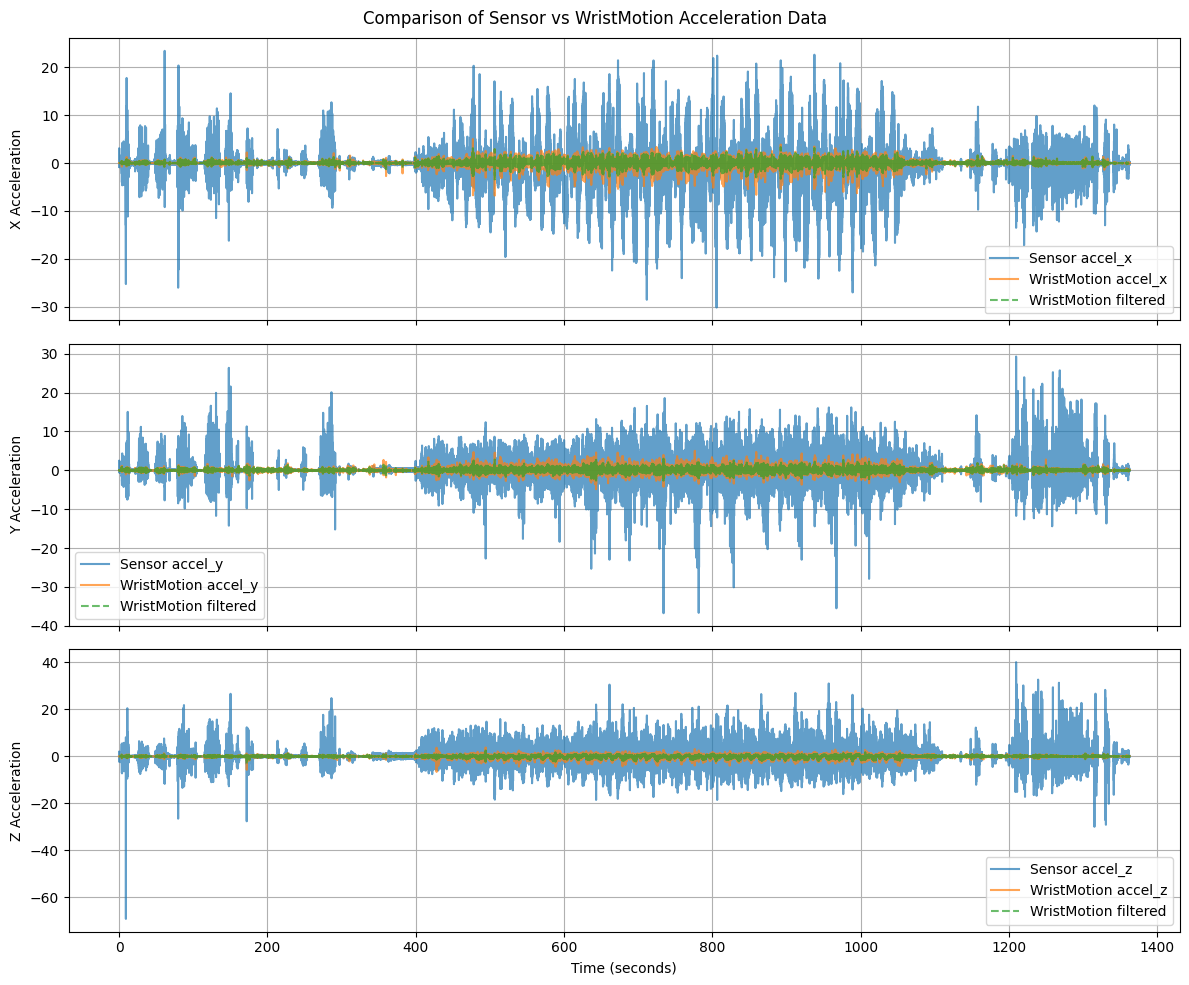

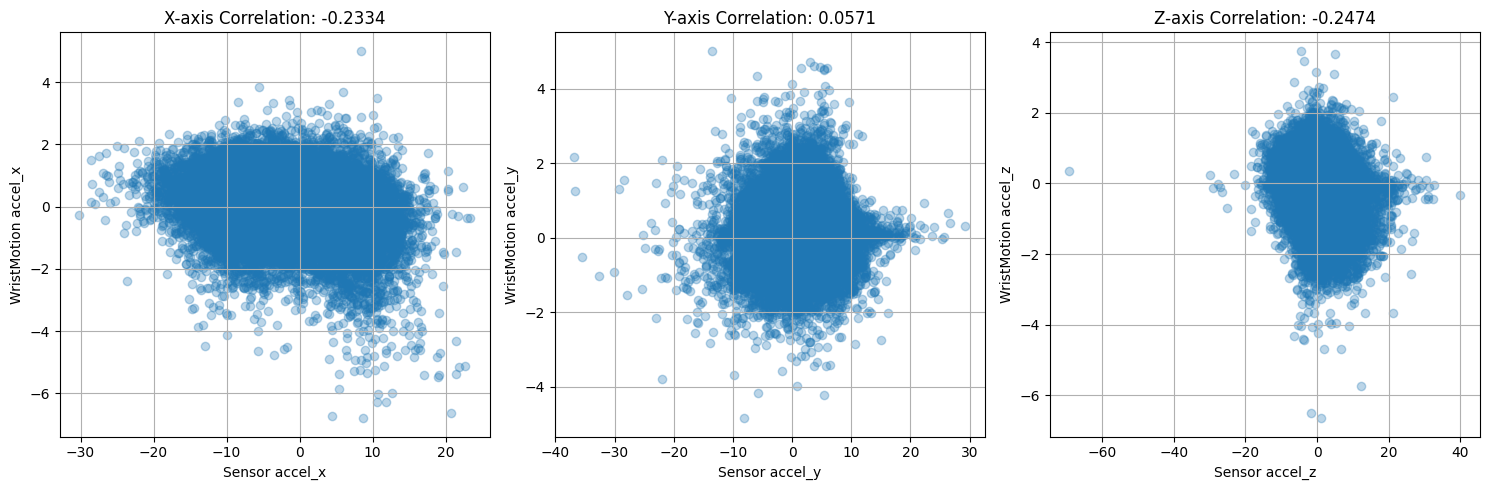

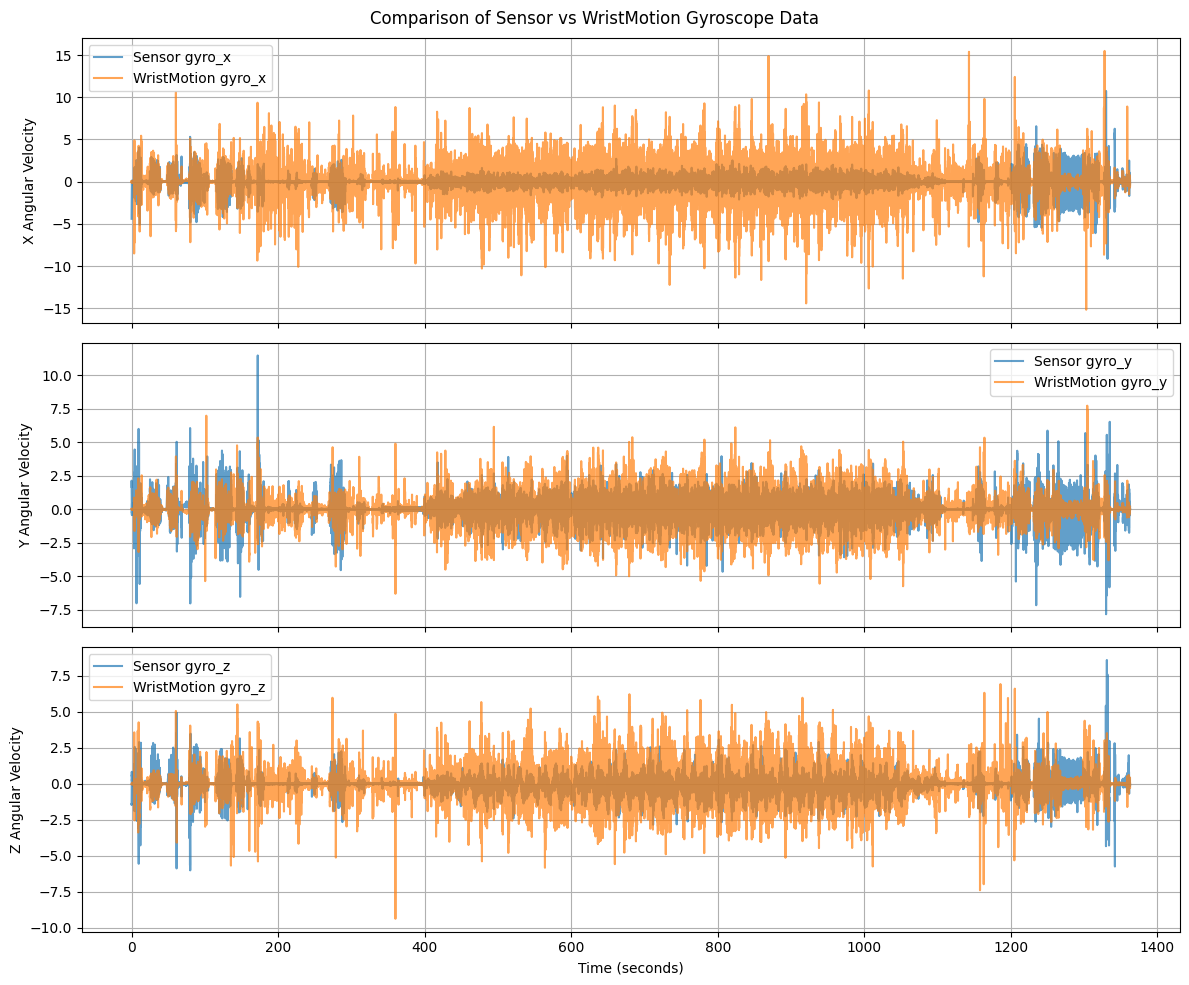

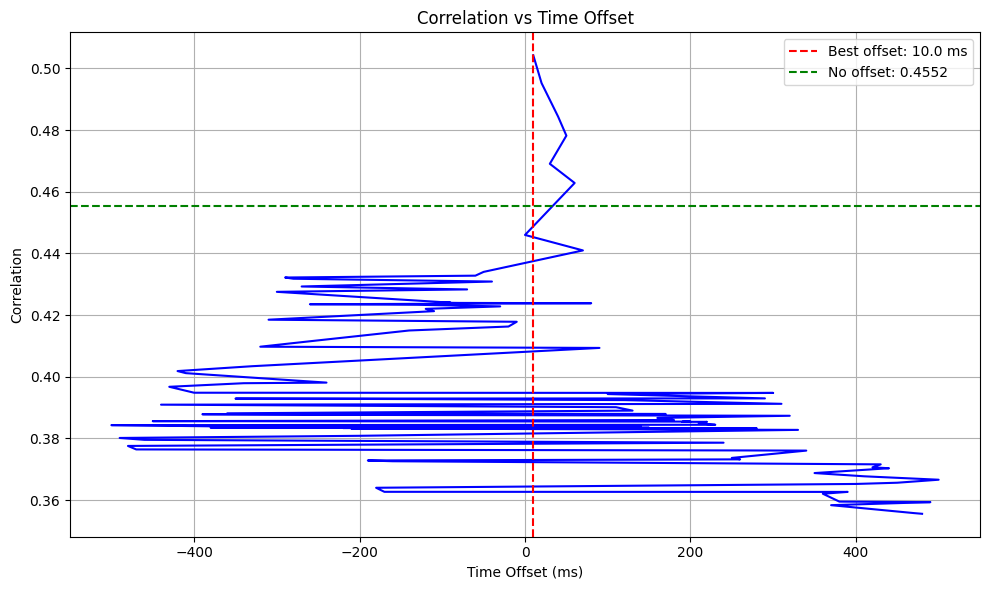

In [50]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dateutil import parser
from scipy import interpolate
from scipy.signal import butter, filtfilt

# Path to the SQLite database
db_path = '/Users/nathanverrill/Boschertown/gateway/gateway-1.sqlite'

def synchronize_sensor_data(db_path):
    """
    Load sensor data and align WristMotion data to it without modifying the original sensor data.
    """
    try:
        # Connect to the database
        conn = sqlite3.connect(db_path)
        
        # Step 1: Load sensor data (IMU tables joined on utc_time)
        print("Loading sensor data...")
        sensor_tables = ['Orientation', 'Compass', 'Accelerometer', 'Gyroscope', 'Magnetometer']
        
        # Build the JOIN query for sensor data
        join_parts = ["SELECT t1.utc_time"]
        from_clause = [f"FROM {sensor_tables[0]} t1"]
        
        # Add specific columns of interest
        sensor_cols = []
        for i, table in enumerate(sensor_tables):
            table_idx = i + 1
            
            if i > 0:
                from_clause.append(f"INNER JOIN {table} t{table_idx} ON t1.utc_time = t{table_idx}.utc_time")
            
            # Add relevant columns from each table
            if table == 'Accelerometer':
                join_parts.append(f", t{table_idx}.x AS accel_x, t{table_idx}.y AS accel_y, t{table_idx}.z AS accel_z")
                sensor_cols.extend(['accel_x', 'accel_y', 'accel_z'])
            elif table == 'Gyroscope':
                join_parts.append(f", t{table_idx}.x AS gyro_x, t{table_idx}.y AS gyro_y, t{table_idx}.z AS gyro_z")
                sensor_cols.extend(['gyro_x', 'gyro_y', 'gyro_z'])
            elif table == 'Magnetometer':
                join_parts.append(f", t{table_idx}.x AS mag_x, t{table_idx}.y AS mag_y, t{table_idx}.z AS mag_z")
                sensor_cols.extend(['mag_x', 'mag_y', 'mag_z'])
                
        # Complete the query
        sensor_query = " ".join(join_parts) + " " + " ".join(from_clause)
        
        # Load the data
        sensors_df = pd.read_sql_query(sensor_query, conn)
        print(f"Loaded {len(sensors_df)} rows of sensor data")
        
        # Step 2: Convert ISO timestamps to Unix epoch in nanoseconds
        print("Converting sensor timestamps...")
        sensors_df['timestamp_ns'] = sensors_df['utc_time'].apply(
            lambda x: int(parser.parse(x).timestamp() * 1e9)
        )
        
        # Step 3: Load WristMotion data with the correct column names
        print("Loading WristMotion data...")
        wm_query = """SELECT time, accelerationX, accelerationY, accelerationZ, 
                      rotationRateX, rotationRateY, rotationRateZ, 
                      quaternionW, quaternionX, quaternionY, quaternionZ,
                      pitch, roll, yaw
                      FROM WristMotion"""
        wm_df = pd.read_sql_query(wm_query, conn)
        print(f"Loaded {len(wm_df)} rows of WristMotion data")
        
        # Rename WristMotion columns for clarity
        wm_df = wm_df.rename(columns={
            'time': 'timestamp_ns',
            'accelerationX': 'wm_accel_x',
            'accelerationY': 'wm_accel_y',
            'accelerationZ': 'wm_accel_z',
            'rotationRateX': 'wm_gyro_x',
            'rotationRateY': 'wm_gyro_y',
            'rotationRateZ': 'wm_gyro_z',
            'quaternionW': 'wm_quat_w',
            'quaternionX': 'wm_quat_x',
            'quaternionY': 'wm_quat_y',
            'quaternionZ': 'wm_quat_z',
            'pitch': 'wm_pitch',
            'roll': 'wm_roll',
            'yaw': 'wm_yaw'
        })
        
        # Step 4: Check time range overlap
        sensor_start = sensors_df['timestamp_ns'].min()
        sensor_end = sensors_df['timestamp_ns'].max()
        wm_start = wm_df['timestamp_ns'].min()
        wm_end = wm_df['timestamp_ns'].max()
        
        print("\nTimestamp ranges (nanoseconds since epoch):")
        print(f"Sensors: {sensor_start} to {sensor_end}")
        print(f"WristMotion: {wm_start} to {wm_end}")
        
        # Check for overlap
        if sensor_end < wm_start or wm_end < sensor_start:
            print("WARNING: No time overlap between datasets!")
            return
            
        # Find the overlapping time range
        start_time = max(sensor_start, wm_start)
        end_time = min(sensor_end, wm_end)
        
        print(f"Overlapping time range: {start_time} to {end_time}")
        
        # Step 5: Filter data to overlapping time range
        sensors_filtered = sensors_df[(sensors_df['timestamp_ns'] >= start_time) & 
                                     (sensors_df['timestamp_ns'] <= end_time)].copy()
        wm_filtered = wm_df[(wm_df['timestamp_ns'] >= start_time) & 
                           (wm_df['timestamp_ns'] <= end_time)].copy()
        
        print(f"Filtered data points - Sensors: {len(sensors_filtered)}, WristMotion: {len(wm_filtered)}")
                
                
        # Step 6: Keep sensor data as is, and interpolate WristMotion data to match sensor timestamps
        print("Interpolating WristMotion data to match sensor timestamps...")

        # Use the sensor timestamps as our reference time points
        reference_timestamps = sensors_filtered['timestamp_ns'].values

        # Convert timestamps to seconds for better readability
        sensors_filtered['time_sec'] = (sensors_filtered['timestamp_ns'] - start_time) / 1e9

        # Create interpolation functions for WristMotion data
        # Group columns by data type
        linear_cols = ['wm_accel_x', 'wm_accel_y', 'wm_accel_z', 'wm_gyro_x', 'wm_gyro_y', 'wm_gyro_z']
        angle_cols = ['wm_pitch', 'wm_roll', 'wm_yaw']
        quat_cols = ['wm_quat_w', 'wm_quat_x', 'wm_quat_y', 'wm_quat_z']

        aligned_wm_data = {}

        # Standard linear interpolation for acceleration and gyroscope data
        for col in linear_cols:
            if col in wm_filtered.columns:
                f = interpolate.interp1d(wm_filtered['timestamp_ns'], 
                                        wm_filtered[col],
                                        bounds_error=False, 
                                        fill_value="extrapolate")
                
                # Interpolate WristMotion data to match sensor timestamps
                aligned_wm_data[col] = f(reference_timestamps)

        # Handle Euler angles (pitch, roll, yaw) with care for wrap-around
        for col in angle_cols:
            if col in wm_filtered.columns:
                # Convert angles to complex numbers to handle wrap-around properly
                angles_rad = np.deg2rad(wm_filtered[col].values)
                complex_angles = np.exp(1j * angles_rad)
                
                # Interpolate real and imaginary parts separately
                real_interp = interpolate.interp1d(wm_filtered['timestamp_ns'], 
                                                np.real(complex_angles),
                                                bounds_error=False, 
                                                fill_value="extrapolate")
                imag_interp = interpolate.interp1d(wm_filtered['timestamp_ns'], 
                                                np.imag(complex_angles),
                                                bounds_error=False, 
                                                fill_value="extrapolate")
                
                # Reconstruct angles from interpolated complex values
                real_part = real_interp(reference_timestamps)
                imag_part = imag_interp(reference_timestamps)
                interp_angles = np.rad2deg(np.angle(real_part + 1j * imag_part))
                
                aligned_wm_data[col] = interp_angles

        # Handle quaternions with normalized linear interpolation
        # This is a more efficient approximation to SLERP that works well for small angles
        if all(col in wm_filtered.columns for col in quat_cols):
            for col in quat_cols:
                # Use standard linear interpolation for each quaternion component
                f = interpolate.interp1d(wm_filtered['timestamp_ns'], 
                                        wm_filtered[col],
                                        bounds_error=False, 
                                        fill_value="extrapolate")
                
                aligned_wm_data[col] = f(reference_timestamps)
            
            # Normalize the quaternions after interpolation
            quat_norm = np.sqrt(
                aligned_wm_data['wm_quat_w']**2 +
                aligned_wm_data['wm_quat_x']**2 +
                aligned_wm_data['wm_quat_y']**2 +
                aligned_wm_data['wm_quat_z']**2
            )
            
            for col in quat_cols:
                aligned_wm_data[col] /= quat_norm

        # Add the aligned WristMotion data to the sensor dataframe
        for col, values in aligned_wm_data.items():
            sensors_filtered[col] = values
        
        
        
        # Step 7: Optional filtering for WristMotion data only
        def butter_lowpass_filter(data, cutoff, fs, order=5):
            nyq = 0.5 * fs
            normal_cutoff = cutoff / nyq
            b, a = butter(order, normal_cutoff, btype='low', analog=False)
            y = filtfilt(b, a, data)
            return y
        
        # Calculate sampling frequency from sensor data
        if len(reference_timestamps) > 1:
            time_diffs = np.diff(reference_timestamps)
            avg_diff_ns = np.mean(time_diffs)
            sensor_freq = 1e9 / avg_diff_ns
            print(f"Sensor sampling frequency: {sensor_freq:.2f} Hz")
            
            # Apply filtering to WristMotion data only
            cutoff = 10  # Hz
            for axis_suffix in ['x', 'y', 'z']:
                wm_col = f'wm_accel_{axis_suffix}'
                if wm_col in sensors_filtered.columns:
                    sensors_filtered[f'{wm_col}_filtered'] = butter_lowpass_filter(
                        sensors_filtered[wm_col], cutoff, sensor_freq
                    )
        
        # Step 8: Compare the data
        print("\nComparison statistics for acceleration data:")
        
        # Calculate correlation between sensor and WristMotion acceleration
        if set(['accel_x', 'accel_y', 'accel_z']).issubset(sensors_filtered.columns) and \
           set(['wm_accel_x', 'wm_accel_y', 'wm_accel_z']).issubset(sensors_filtered.columns):
            
            corr_x = np.corrcoef(sensors_filtered['accel_x'], sensors_filtered['wm_accel_x'])[0, 1]
            corr_y = np.corrcoef(sensors_filtered['accel_y'], sensors_filtered['wm_accel_y'])[0, 1]
            corr_z = np.corrcoef(sensors_filtered['accel_z'], sensors_filtered['wm_accel_z'])[0, 1]
            
            print(f"Correlation between sensor and WristMotion acceleration:")
            print(f"X-axis: {corr_x:.4f}")
            print(f"Y-axis: {corr_y:.4f}")
            print(f"Z-axis: {corr_z:.4f}")
            
            # Calculate RMS error
            rmse_x = np.sqrt(np.mean((sensors_filtered['accel_x'] - sensors_filtered['wm_accel_x'])**2))
            rmse_y = np.sqrt(np.mean((sensors_filtered['accel_y'] - sensors_filtered['wm_accel_y'])**2))
            rmse_z = np.sqrt(np.mean((sensors_filtered['accel_z'] - sensors_filtered['wm_accel_z'])**2))
            
            print(f"RMSE between sensor and WristMotion acceleration:")
            print(f"X-axis: {rmse_x:.4f}")
            print(f"Y-axis: {rmse_y:.4f}")
            print(f"Z-axis: {rmse_z:.4f}")
        
        # Step 9: Visualize the data
        print("\nCreating visualization...")
        
        # Plot the acceleration data from both sources
        if set(['accel_x', 'accel_y', 'accel_z']).issubset(sensors_filtered.columns) and \
           set(['wm_accel_x', 'wm_accel_y', 'wm_accel_z']).issubset(sensors_filtered.columns):
            
            # Create a figure with 3 subplots (one for each axis)
            fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
            
            # Plot X axis
            axes[0].plot(sensors_filtered['time_sec'], sensors_filtered['accel_x'], 
                        label='Sensor accel_x', alpha=0.7)
            axes[0].plot(sensors_filtered['time_sec'], sensors_filtered['wm_accel_x'], 
                        label='WristMotion accel_x', alpha=0.7)
            if 'wm_accel_x_filtered' in sensors_filtered.columns:
                axes[0].plot(sensors_filtered['time_sec'], sensors_filtered['wm_accel_x_filtered'], 
                        label='WristMotion filtered', alpha=0.7, linestyle='--')
            axes[0].set_ylabel('X Acceleration')
            axes[0].legend()
            axes[0].grid(True)
            
            # Plot Y axis
            axes[1].plot(sensors_filtered['time_sec'], sensors_filtered['accel_y'], 
                        label='Sensor accel_y', alpha=0.7)
            axes[1].plot(sensors_filtered['time_sec'], sensors_filtered['wm_accel_y'], 
                        label='WristMotion accel_y', alpha=0.7)
            if 'wm_accel_y_filtered' in sensors_filtered.columns:
                axes[1].plot(sensors_filtered['time_sec'], sensors_filtered['wm_accel_y_filtered'], 
                        label='WristMotion filtered', alpha=0.7, linestyle='--')
            axes[1].set_ylabel('Y Acceleration')
            axes[1].legend()
            axes[1].grid(True)
            
            # Plot Z axis
            axes[2].plot(sensors_filtered['time_sec'], sensors_filtered['accel_z'], 
                        label='Sensor accel_z', alpha=0.7)
            axes[2].plot(sensors_filtered['time_sec'], sensors_filtered['wm_accel_z'], 
                        label='WristMotion accel_z', alpha=0.7)
            if 'wm_accel_z_filtered' in sensors_filtered.columns:
                axes[2].plot(sensors_filtered['time_sec'], sensors_filtered['wm_accel_z_filtered'], 
                        label='WristMotion filtered', alpha=0.7, linestyle='--')
            axes[2].set_xlabel('Time (seconds)')
            axes[2].set_ylabel('Z Acceleration')
            axes[2].legend()
            axes[2].grid(True)
            
            plt.suptitle('Comparison of Sensor vs WristMotion Acceleration Data')
            plt.tight_layout()
            plt.savefig('sensor_comparison.png', dpi=300)
            print("Visualization saved as 'sensor_comparison.png'")
            
            # Additional plot: Scatter plot to show correlation
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            axes[0].scatter(sensors_filtered['accel_x'], sensors_filtered['wm_accel_x'], alpha=0.3)
            axes[0].set_xlabel('Sensor accel_x')
            axes[0].set_ylabel('WristMotion accel_x')
            axes[0].set_title(f'X-axis Correlation: {corr_x:.4f}')
            axes[0].grid(True)
            
            axes[1].scatter(sensors_filtered['accel_y'], sensors_filtered['wm_accel_y'], alpha=0.3)
            axes[1].set_xlabel('Sensor accel_y')
            axes[1].set_ylabel('WristMotion accel_y')
            axes[1].set_title(f'Y-axis Correlation: {corr_y:.4f}')
            axes[1].grid(True)
            
            axes[2].scatter(sensors_filtered['accel_z'], sensors_filtered['wm_accel_z'], alpha=0.3)
            axes[2].set_xlabel('Sensor accel_z')
            axes[2].set_ylabel('WristMotion accel_z')
            axes[2].set_title(f'Z-axis Correlation: {corr_z:.4f}')
            
            axes[2].grid(True)
            
            plt.tight_layout()
            plt.savefig('sensor_correlation.png', dpi=300)
            print("Correlation plots saved as 'sensor_correlation.png'")
            
        # Also compare gyroscope data if available
        if set(['gyro_x', 'gyro_y', 'gyro_z']).issubset(sensors_filtered.columns) and \
           set(['wm_gyro_x', 'wm_gyro_y', 'wm_gyro_z']).issubset(sensors_filtered.columns):
            
            # Calculate correlation for gyroscope data
            gyro_corr_x = np.corrcoef(sensors_filtered['gyro_x'], sensors_filtered['wm_gyro_x'])[0, 1]
            gyro_corr_y = np.corrcoef(sensors_filtered['gyro_y'], sensors_filtered['wm_gyro_y'])[0, 1]
            gyro_corr_z = np.corrcoef(sensors_filtered['gyro_z'], sensors_filtered['wm_gyro_z'])[0, 1]
            
            print(f"\nCorrelation between sensor and WristMotion gyroscope:")
            print(f"X-axis: {gyro_corr_x:.4f}")
            print(f"Y-axis: {gyro_corr_y:.4f}")
            print(f"Z-axis: {gyro_corr_z:.4f}")
            
            # Create visualization for gyroscope data
            fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
            
            axes[0].plot(sensors_filtered['time_sec'], sensors_filtered['gyro_x'], 
                        label='Sensor gyro_x', alpha=0.7)
            axes[0].plot(sensors_filtered['time_sec'], sensors_filtered['wm_gyro_x'], 
                        label='WristMotion gyro_x', alpha=0.7)
            axes[0].set_ylabel('X Angular Velocity')
            axes[0].legend()
            axes[0].grid(True)
            
            axes[1].plot(sensors_filtered['time_sec'], sensors_filtered['gyro_y'], 
                        label='Sensor gyro_y', alpha=0.7)
            axes[1].plot(sensors_filtered['time_sec'], sensors_filtered['wm_gyro_y'], 
                        label='WristMotion gyro_y', alpha=0.7)
            axes[1].set_ylabel('Y Angular Velocity')
            axes[1].legend()
            axes[1].grid(True)
            
            axes[2].plot(sensors_filtered['time_sec'], sensors_filtered['gyro_z'], 
                        label='Sensor gyro_z', alpha=0.7)
            axes[2].plot(sensors_filtered['time_sec'], sensors_filtered['wm_gyro_z'], 
                        label='WristMotion gyro_z', alpha=0.7)
            axes[2].set_xlabel('Time (seconds)')
            axes[2].set_ylabel('Z Angular Velocity')
            axes[2].legend()
            axes[2].grid(True)
            
            plt.suptitle('Comparison of Sensor vs WristMotion Gyroscope Data')
            plt.tight_layout()
            plt.savefig('gyro_comparison.png', dpi=300)
            print("Gyroscope comparison saved as 'gyro_comparison.png'")
        
        # Step 10: Save the aligned data to a CSV file
        output_file = '/Users/nathanverrill/Boschertown/gateway/gateway-1-aligned_sensor_data.csv'
        sensors_filtered.to_csv(output_file, index=False)
        print(f"Aligned data saved to {output_file}")
        
        # Step 11: Calculate time offset statistics
        if len(sensors_filtered) > 0:
            # Calculate the time offset distribution based on signal correlation
            print("\nAnalyzing potential time offsets between datasets...")
            
            # Use a small window of data for correlation analysis (to avoid excessive computation)
            window_size = min(1000, len(sensors_filtered))
            window_data = sensors_filtered.head(window_size).copy()
            
            # Try different time offsets to find the best correlation
            max_offset_sec = 0.5  # Try offsets up to 500ms in either direction
            step_size_sec = 0.01  # 10ms steps
            
            offset_range = np.arange(-max_offset_sec, max_offset_sec+step_size_sec, step_size_sec)
            correlations = []
            
            # Calculate time offsets only for acceleration data
            if set(['accel_x', 'accel_y', 'accel_z']).issubset(window_data.columns) and \
               set(['wm_accel_x', 'wm_accel_y', 'wm_accel_z']).issubset(window_data.columns):
                
                # Compute total acceleration magnitude for both sensors
                window_data['accel_mag'] = np.sqrt(
                    window_data['accel_x']**2 + 
                    window_data['accel_y']**2 + 
                    window_data['accel_z']**2
                )
                
                window_data['wm_accel_mag'] = np.sqrt(
                    window_data['wm_accel_x']**2 + 
                    window_data['wm_accel_y']**2 + 
                    window_data['wm_accel_z']**2
                )
                
                # Original correlation without any offset
                base_corr = np.corrcoef(window_data['accel_mag'], window_data['wm_accel_mag'])[0, 1]
                print(f"Base correlation with no offset: {base_corr:.4f}")
                
                for offset_sec in offset_range:
                    # Create time offset by shifting the time_sec column
                    offset_time = window_data['time_sec'] + offset_sec
                    
                    # Interpolate WristMotion data to the offset timestamps
                    f = interpolate.interp1d(
                        window_data['time_sec'], 
                        window_data['wm_accel_mag'],
                        bounds_error=False, 
                        fill_value="extrapolate"
                    )
                    
                    offset_wm = f(offset_time)
                    
                    # Calculate correlation with this offset
                    corr = np.corrcoef(window_data['accel_mag'][10:-10], offset_wm[10:-10])[0, 1]
                    correlations.append((offset_sec, corr))
                
                # Find the offset with the highest correlation
                correlations.sort(key=lambda x: x[1], reverse=True)
                best_offset, best_corr = correlations[0]
                
                print(f"\nBest time offset: {best_offset*1000:.1f} ms")
                print(f"Correlation at this offset: {best_corr:.4f}")
                print(f"Correlation improvement: {(best_corr - base_corr)*100:.2f}%")
                
                # Plot correlation as a function of time offset
                corr_df = pd.DataFrame(correlations, columns=['offset_sec', 'correlation'])
                
                plt.figure(figsize=(10, 6))
                plt.plot(corr_df['offset_sec']*1000, corr_df['correlation'], 'b-')
                plt.axvline(x=best_offset*1000, color='r', linestyle='--', 
                           label=f'Best offset: {best_offset*1000:.1f} ms')
                plt.axhline(y=base_corr, color='g', linestyle='--', 
                           label=f'No offset: {base_corr:.4f}')
                plt.xlabel('Time Offset (ms)')
                plt.ylabel('Correlation')
                plt.title('Correlation vs Time Offset')
                plt.grid(True)
                plt.legend()
                plt.tight_layout()
                plt.savefig('time_offset_analysis.png', dpi=300)
                print("Time offset analysis saved as 'time_offset_analysis.png'")
        
        return sensors_filtered
        
    except Exception as e:
        print(f"Error: {str(e)}")
        import traceback
        traceback.print_exc()
    finally:
        if 'conn' in locals():
            conn.close()

if __name__ == "__main__":
    wrist_db = synchronize_sensor_data(db_path)
            

In [51]:
wrist_db.head()

,utc_time,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,...,wm_pitch,wm_roll,wm_yaw,wm_quat_w,wm_quat_x,wm_quat_y,wm_quat_z,wm_accel_x_filtered,wm_accel_y_filtered,wm_accel_z_filtered
12,2025-10-02T21:46:18.786Z,-0.308505,1.996014,1.321476,-4.397555,1.666460,-1.398087,-40.839130,-42.665920,18.275467,...,0.354887,0.174344,2.503300,0.293065,-0.026195,0.193851,0.935868,-0.005368,-0.006181,0.003063
13,2025-10-02T21:46:18.796Z,-0.517297,1.872705,0.779365,-4.337376,1.726055,-1.453750,-41.144283,-43.696983,17.056435,...,0.355019,0.174302,2.503371,0.293027,-0.026161,0.193905,0.935869,-0.005882,-0.011963,0.006689
14,2025-10-02T21:46:18.806Z,-0.492368,1.666074,0.270030,-4.239384,1.861996,-1.470463,-40.283920,-43.941971,15.591248,...,0.354503,0.174226,2.503553,0.292985,-0.026226,0.193653,0.935933,-0.006311,-0.015305,0.009385
15,2025-10-02T21:46:18.817Z,-0.357492,1.523235,-0.077121,-3.980420,2.103470,-1.420125,-39.963341,-44.810863,14.306381,...,0.353274,0.174134,2.503908,0.292911,-0.026416,0.193066,0.936072,-0.006518,-0.014641,0.010513
16,2025-10-02T21:46:18.827Z,-0.129384,1.548366,-1.716421,-3.727711,2.126785,-1.361458,-38.429615,-44.580002,12.209259,...,0.351764,0.174029,2.504323,0.292830,-0.026649,0.192345,0.936239,-0.006322,-0.009829,0.009905


In [52]:
wrist_db.columns

Index(['utc_time', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y',
       'gyro_z', 'mag_x', 'mag_y', 'mag_z', 'timestamp_ns', 'time_sec',
       'wm_accel_x', 'wm_accel_y', 'wm_accel_z', 'wm_gyro_x', 'wm_gyro_y',
       'wm_gyro_z', 'wm_pitch', 'wm_roll', 'wm_yaw', 'wm_quat_w', 'wm_quat_x',
       'wm_quat_y', 'wm_quat_z', 'wm_accel_x_filtered', 'wm_accel_y_filtered',
       'wm_accel_z_filtered'],
      dtype='object')

In [53]:
df.head()

,time,seconds_elapsed,yaw,qx,qz,roll,qw,qy,pitch,utc_time,...,Gyroscope_time,Gyroscope_seconds_elapsed,Gyroscope_z,Gyroscope_y,Gyroscope_x,Magnetometer_time,Magnetometer_seconds_elapsed,Magnetometer_z,Magnetometer_y,Magnetometer_x
0,1759441578666167800,0.103168,-2.429523,-0.647097,-0.588150,-1.976578,-0.126799,-0.468260,0.796505,2025-10-02T21:46:18.666Z,...,1759441578666167800,0.103168,-0.890061,0.824522,-2.084948,1759441578666167800,0.103168,30.394394,-23.196554,-27.954477
1,1759441578676223700,0.113224,-2.455522,-0.641010,-0.595674,-1.949456,-0.134967,-0.464824,0.813649,2025-10-02T21:46:18.676Z,...,1759441578676223700,0.113224,-0.944620,0.995692,-2.399902,1759441578676223700,0.113224,29.906376,-23.940651,-28.289244
2,1759441578686280700,0.123281,-2.486636,-0.633887,-0.604353,-1.916385,-0.143834,-0.460713,0.831905,2025-10-02T21:46:18.686Z,...,1759441578686280700,0.123281,-0.998618,1.161171,-2.711748,1759441578686280700,0.123281,28.547432,-25.920223,-29.514662
3,1759441578696336600,0.133337,-2.523126,-0.625801,-0.613990,-1.877358,-0.153379,-0.455921,0.850836,2025-10-02T21:46:18.696Z,...,1759441578696336600,0.133337,-1.043888,1.270960,-3.001779,1759441578696336600,0.133337,27.240368,-27.809851,-30.635431
4,1759441578706392800,0.143393,-2.565328,-0.616865,-0.624368,-1.832417,-0.163612,-0.450414,0.869958,2025-10-02T21:46:18.706Z,...,1759441578706392800,0.143393,-1.082720,1.359269,-3.271661,1759441578706392800,0.143393,26.394039,-29.793200,-32.008366


In [57]:
def load_location_data(db_path):
    """
    Load location data from the Location table in the database
    """
    # Connect to the database
    conn = sqlite3.connect(db_path)
    
    # Query to load location data
    location_query = "SELECT * FROM Location"
    
    # Load the data
    locations_df = pd.read_sql_query(location_query, conn)
    print(f"Loaded {len(locations_df)} rows of location data")
    
    # Print the columns
    print("\nLocation data columns:")
    print(locations_df.columns.tolist())
    
    # Convert ISO timestamps to datetime for analysis
    if 'utc_time' in locations_df.columns:
        locations_df['datetime'] = pd.to_datetime(locations_df['utc_time'])
        
        # Print start and end times
        start_time = locations_df['datetime'].min()
        end_time = locations_df['datetime'].max()
        duration = end_time - start_time
        
        print(f"\nTime range: {start_time} to {end_time}")
        print(f"Duration: {duration}")
        
        # Calculate frequency
        if len(locations_df) > 1:
            time_diffs = locations_df['datetime'].diff().dropna()
            avg_diff = time_diffs.mean()
            median_diff = time_diffs.median()
            
            print(f"Average time between records: {avg_diff}")
            print(f"Median time between records: {median_diff}")
            print(f"Approximate frequency: {1/avg_diff.total_seconds():.2f} Hz")
    
    # Close the connection
    conn.close()
    
    return locations_df

# Load location data
if __name__ == "__main__":
    locations_df = load_location_data(db_path)

Loaded 1364 rows of location data

Location data columns:
['time', 'seconds_elapsed', 'altitude', 'speedAccuracy', 'bearingAccuracy', 'latitude', 'altitudeAboveMeanSeaLevel', 'bearing', 'horizontalAccuracy', 'verticalAccuracy', 'longitude', 'speed', 'utc_time']

Time range: 2025-10-02 21:46:18+00:00 to 2025-10-02 22:09:00.999000+00:00
Duration: 0 days 00:22:42.999000
Average time between records: 0 days 00:00:00.999999266
Median time between records: 0 days 00:00:01
Approximate frequency: 1.00 Hz
